In [8]:
# SETUP FETCH ENV VARIABLES
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

print("keys set")


keys set


In [9]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile", temperature=0.7)

print(model)

profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x0000029FC5083170> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029FC50822D0> model_name='llama-3.3-70b-versatile' model_kwargs={} groq_api_key=SecretStr('**********')


In [15]:
from langchain_tavily import TavilySearch
tavily = TavilySearch(max_results=5,topic="general")
tavily.invoke("What is the capital of France?")


{'query': 'What is the capital of France?',
 'response_time': 1.26,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://simple.wikipedia.org/wiki/Capital_of_France',
   'title': 'Capital of France - Simple English Wikipedia, the free encyclopedia',
   'content': 'The **capital of France** is Paris. In the course of history, the national capital has been in many locations other than Paris. * Versailles (1871–1879) The French Third Republic established Versailles as its seat of government in March 1871 after the Paris Commune took control of Paris. * Bordeaux (September 1914) The French government was relocated from Paris to Bordeaux very briefly during World War I, when it was feared that Paris would soon fall into German hands. * Tours (10–13 June 1940) Tours served as the temporary capital of France during the Second World War after the government fled Paris due to the German advance. * Bordeaux (June 1940) The French government was relocated fr

In [13]:
from langchain_community.utilities import GoogleSerperAPIWrapper
google_search = GoogleSerperAPIWrapper()

print(google_search.run("What is the capital of France?"))

Paris


In [16]:
def tavily_search(query: str) -> str:
    """Searches the web using Tavily and returns the results as a string."""
    return tavily.invoke({"query": query})

def google_serper_search(query: str) -> str:
    """Searches the web using Google Serper and returns the results as a string."""
    return google_search.run(query)


In [18]:
tavily_results = tavily_search("Plan trip to India?")
print("Tavily Search Results:")
print(tavily_results)

Tavily Search Results:
{'query': 'Plan trip to India?', 'response_time': 0.8, 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://grrrltraveler.com/how-to-plan-your-first-trip-to-india/', 'title': 'My Ultimate Guide for Planning your First Trip to India - grrrltraveler', 'content': 'In trip planning for India, there are two things I recommend travelers to look at:. When planning my India trip itinerary, I map out a route that is convenient for efficient travel. Distances you will travel in India, from city to city can take anywhere from two hours to a day. ## Top 5 routes that travelers take in India. My favorite India Travel forum is **IndiaMike.com** – it’s a great resource with an active Indian community around trip planning. # How much does it cost to travel India ? When I was traveling India this last trip, I was unemployed, traveling for several months and also adding on other countries, flights and visas. source=bk&t=grrrltraveler 20&bm id=def

Agent created successfully.


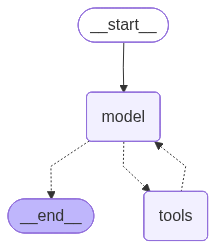

In [20]:
from langchain.agents import create_agent

system_prompt = """You are a helpful travel assistant that helps users plan their trips. You can use the following tools to search the web for information about travel destinations, flights, hotels, and more:"""
agent = create_agent(
    tools=[tavily_search, google_serper_search],model=model, system_prompt=system_prompt)

print("Agent created successfully.")
agent

In [27]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Three day trip plan to kasol, Himachal Pradesh. I want to visit the waterfalls and try some local food.",
            }
        ]
    }
)

print("Agent Response:")


Agent Response:


In [28]:
response["messages"]

final_response = response["messages"][-1].content

print(final_response)

Here's a 3-day trip plan to Kasol, Himachal Pradesh:

Day 1: 
- Arrive at Bhuntar by bus and take a local ride to Kasol (₹100–₹150).
- Explore the small Kasol market, try momos or maggi at roadside stalls, and watch the sun dip behind the hills from the riverside trail.

Day 2: 
- Visit Tosh village, which is not far from Kasol.
- Enjoy waterfalls, night star gazing, and trekking.

Day 3: 
- Trek to Kheerganga.

You can also explore water rafting while coming back from Manali to Kasol. Additionally, you can go to Parvati valley and explore the beauty. In the evening, you can come back to Kasol market for shopping.

Remember to pre-book your hotel in Kasol to take proper rest after a long journey. You can also stay in tents, but it's better to trek down to Kasol and explore the local food in restaurants. 

Note: The cost of the trip can be under Rs 5,000, depending on your stay, food, and local experiences.
